In [95]:
# Data: https://github.com/atilsamancioglu/DeepLearningBootcamp/blob/main/06-study_hours_grades.csv

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

## 🧠 PyTorch Training Süreci

### 1️⃣ Veriyi Hazırla

Modelin öğrenebilmesi için veri seti temizlenir, dönüştürülür ve yüklenir.
👉 Amaç: Modele uygun giriş (input) oluşturmak

---

### 2️⃣ Modeli Kur

Model mimarisi tanımlanır, loss fonksiyonu ve optimizer seçilir.
👉 Amaç: Öğrenme mekanizmasını oluşturmak

---

### 3️⃣ Tahmin Yap (Forward Pass)

Veri modele verilir ve model çıktısı (prediction) elde edilir.
👉 Amaç: Modelin ne tahmin ettiğini görmek

---

### 4️⃣ Modeli Değerlendir (Loss Hesapla)

Tahmin ile gerçek değer karşılaştırılır ve hata (loss) hesaplanır.
👉 Amaç: Model ne kadar yanlış?

---

### 5️⃣ Modeli İyileştir (Backward + Update)

Loss’a göre gradient hesaplanır ve optimizer ile ağırlıklar güncellenir.
👉 Amaç: Modeli daha iyi hale getirmek

---

### 6️⃣ Modeli Kaydet

Eğitilmiş model dosya olarak saklanır.
👉 Amaç: Daha sonra tekrar kullanmak

---

💡 **Kısaca:**
**Data → Model → Prediction → Loss → Update → Save**


In [97]:
# bu veri için gpu'ya gerek yok ama yine de tekrar edelim.
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Device:", device)
print("Device Name:", torch.cuda.get_device_name())

Device: cuda
Device Name: Tesla T4


In [98]:
df = pd.read_csv("06-study_hours_grades.csv")
print(df.shape)
df.head()

(50, 2)


,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


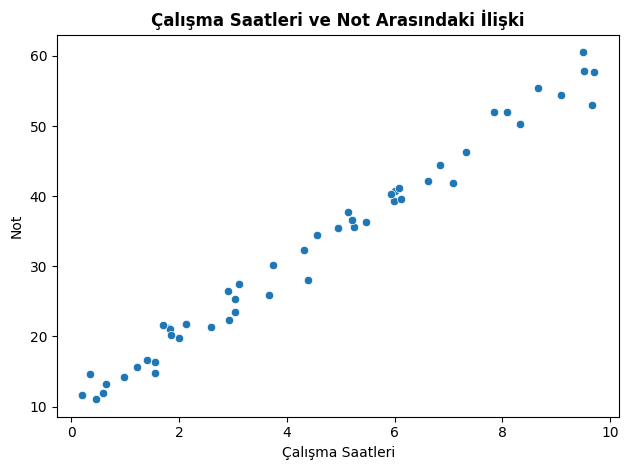

In [100]:
sns.scatterplot(x="study_hours", y="grade", data=df)
plt.title('Çalışma Saatleri ve Not Arasındaki İlişki', fontweight='bold')
plt.xlabel('Çalışma Saatleri')
plt.ylabel('Not')
plt.tight_layout()
plt.show()

In [101]:
df["study_hours"].values # Bu aslında bir NumPy dizisi, bu yüzden bunu kolayca tensörlere dönüştürebiliriz.

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [102]:
torch.tensor(df["study_hours"].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [103]:
# dependent (bağımsız) & independent (bağımlı) değişken
X = torch.tensor(df["study_hours"])
y = torch.tensor(df["grade"])

In [104]:
# train-test split

train_split = int(len(X) * 0.8)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [105]:
X_train

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64)

In [106]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [107]:
# Veriler hazır, şimdi ikinci adıma geçelim
# Ama önce hiç eğitim yapmadan çok basit bir modelle başlayalım ve ne yaptığını görelim

In [108]:
from torch import nn

In [109]:
class SimpleLinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Ağırlık (w) - öğrenilen parametre
        self.weights = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True  # gradient ile güncellenecek
        )

        # Bias (b) - sabit terim
        self.bias = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

    # Modelin ileri yayılımı (tahmin kısmı)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Doğrusal denklem: y = w*x + b
        return self.weights * x + self.bias

In [110]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()
model_0 = torch.compile(model_0)

In [111]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [112]:
model_0.state_dict() # Bu, ağırlıkların ve bias'ın rastgele başlatılmasıdır.

OrderedDict([('_orig_mod.weights', tensor([0.3367])),
             ('_orig_mod.bias', tensor([0.1288]))])

In [113]:
# model eğitimi yapmadık ama yine de bu ağırlık ve bias'a göre bir tahmin yapalım
with torch.inference_mode():
  y_preds = model_0(X_test)

In [114]:
len(X_test), len(y_preds)

(10, 10)

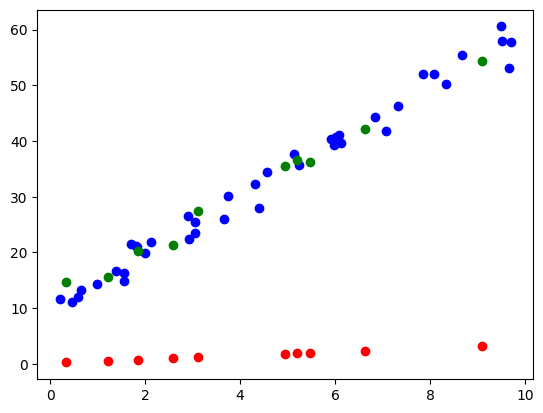

In [115]:
plt.scatter(X_train, y_train, c="b", label="Training data")
plt.scatter(X_test, y_test, c="g", label="Testing data")
plt.scatter(X_test, y_preds, c="r", label="Predictions")
plt.show()

In [116]:
# Gördüğünüz gibi tahminimiz hiç de iyi değil! Çünkü henüz yapay sinir ağını eğitmedik.
# Öncelikle eğitime başlayalım.
# Eğitim döngüsünü oluşturmadan önce, optimizer ve kayıp fonksiyonunu tanımlamamız gerekiyor.

In [117]:
loss_fn = nn.MSELoss() # MSE
#loss_fn = nn.L1Loss() #-> MAE

optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.001)

In [118]:
# Tekrarlanabilir sonuçlar için seed ayarlanır
torch.manual_seed(42)

# Epoch sayısı (modelin veriyi kaç kez göreceği)
epochs = 120

# Eğitim ve test loss değerlerini saklamak için listeler
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    ### 🔵 TRAINING (EĞİTİM AŞAMASI)

    # Modeli eğitim moduna al (dropout/batchnorm varsa önemli)
    model_0.train()

    # 1. Forward pass → Model tahmin üretir
    y_pred = model_0(X_train)

    # 2. Loss hesaplama → Tahmin ile gerçek değer farkı
    loss = loss_fn(y_pred, y_train)

    # 3. Gradientleri sıfırla (birikmeyi önlemek için)
    optimizer.zero_grad()

    # 4. Backward pass → Gradient hesaplama
    loss.backward()

    # 5. Optimizer step → Ağırlıkları güncelle
    optimizer.step()

    ### 🟢 TEST / EVALUATION (DEĞERLENDİRME AŞAMASI)

    # Modeli evaluation moduna al
    model_0.eval()

    # Gradient hesaplamayı kapat (daha hızlı ve memory verimli)
    with torch.inference_mode():

        # 1. Test verisi ile tahmin yap
        test_pred = model_0(X_test)

        # 2. Test loss hesapla
        test_loss = loss_fn(test_pred, y_test.type(torch.float))

        # Her 5 epoch'ta bir sonuçları kaydet ve yazdır
        if epoch % 5 == 0:
            epoch_count.append(epoch)

            # detach(): hesaplama grafiğinden çıkar → numpy'a çevrilebilir
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())

            print(f"Epoch: {epoch} | Train Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Train Loss: 1156.0767463081781 | Test Loss: 858.3089002392693
Epoch: 5 | Train Loss: 633.9334744710083 | Test Loss: 484.2838126795197
Epoch: 10 | Train Loss: 352.99125276114285 | Test Loss: 280.9052321188652
Epoch: 15 | Train Loss: 201.80191856738534 | Test Loss: 169.89189620412714
Epoch: 20 | Train Loss: 120.41268871324436 | Test Loss: 108.98032469406681
Epoch: 25 | Train Loss: 76.57232180621143 | Test Loss: 75.32371818092618
Epoch: 30 | Train Loss: 52.931428428694815 | Test Loss: 56.55034134029036
Epoch: 35 | Train Loss: 40.157054153236494 | Test Loss: 45.94531686432932
Epoch: 40 | Train Loss: 33.22853631952331 | Test Loss: 39.8529199979822
Epoch: 45 | Train Loss: 29.44509239691046 | Test Loss: 36.27478591424398
Epoch: 50 | Train Loss: 27.353849871049174 | Test Loss: 34.112661109416386
Epoch: 55 | Train Loss: 26.173215583708338 | Test Loss: 32.75872389060953
Epoch: 60 | Train Loss: 25.48277112837836 | Test Loss: 31.873639956137755
Epoch: 65 | Train Loss: 25.05632761565991 

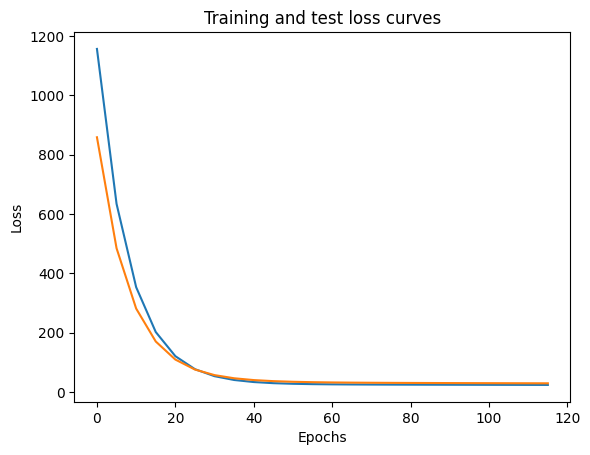

In [119]:
# Kayıp eğrilerini çizin
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [120]:
print(model_0.state_dict())

OrderedDict({'_orig_mod.weights': tensor([6.2983]), '_orig_mod.bias': tensor([1.6607])})


In [121]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

In [122]:
y_preds

tensor([ 9.3471, 32.8485,  3.8266, 58.9326, 17.9595, 43.3885, 21.2933, 34.4162,
        36.0943, 13.3034], dtype=torch.float64)

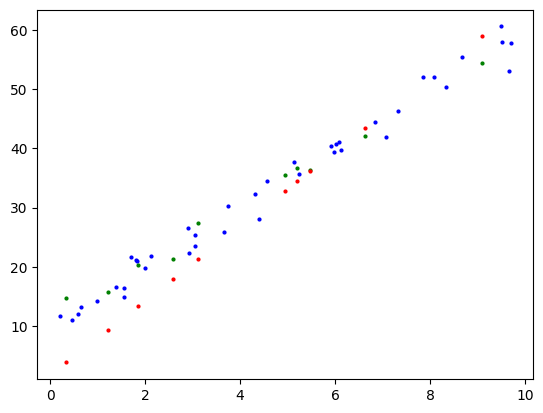

In [123]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")
plt.show()